In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/saniya/Documents/sales-analytics-project/Sample - Superstore.csv', encoding='latin-1')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 9994, Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null

In [9]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum()
category_summary['Margin %'] = (category_summary['Profit'] / category_summary['Sales']) * 100
category_summary = category_summary.round(1)
category_summary

,Sales,Profit,Margin %
Category,,,
Furniture,741999.8,18451.3,2.5
Office Supplies,719047.0,122490.8,17.0
Technology,836154.0,145454.9,17.4


In [11]:
subcat_summary = df.groupby('Sub-Category')[['Sales', 'Profit']].sum()
subcat_summary['Margin %'] = (subcat_summary['Profit'] / subcat_summary['Sales']) * 100
subcat_summary = subcat_summary.round(1).sort_values('Profit')
subcat_summary

,Sales,Profit,Margin %
Sub-Category,,,
Tables,206965.5,-17725.5,-8.6
Bookcases,114880.0,-3472.6,-3.0
Supplies,46673.5,-1189.1,-2.5
Fasteners,3024.3,949.5,31.4
Machines,189238.6,3384.8,1.8
Labels,12486.3,5546.3,44.4
Art,27118.8,6527.8,24.1
Envelopes,16476.4,6964.2,42.3
Furnishings,91705.2,13059.1,14.2


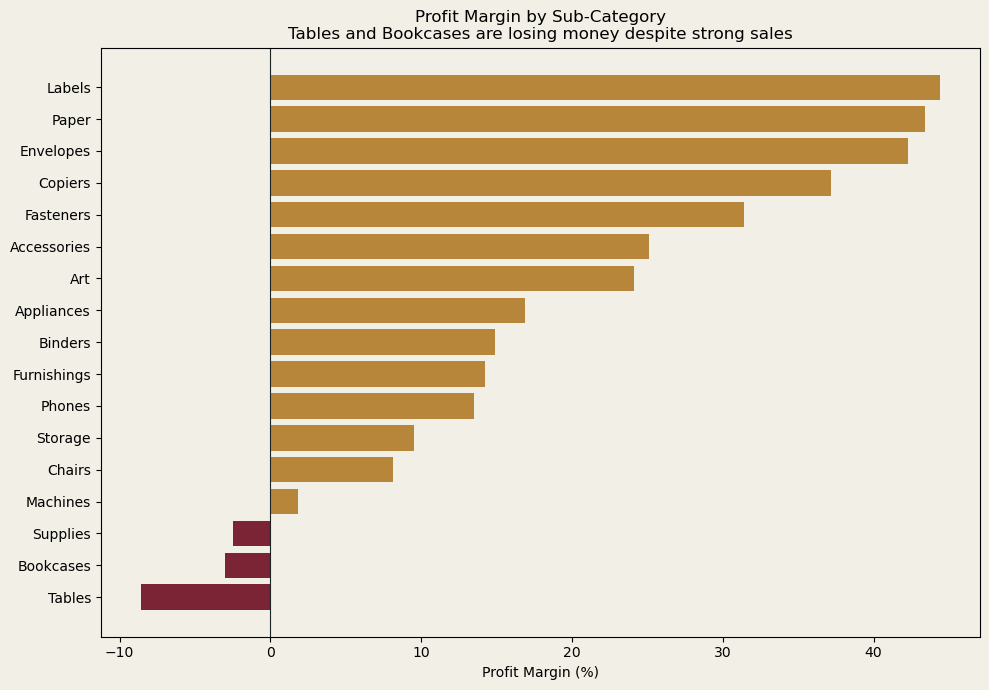

In [13]:
import matplotlib.pyplot as plt

subcat_summary_sorted = subcat_summary.sort_values('Margin %')

colors = ['#7A2436' if x < 0 else '#B8863B' for x in subcat_summary_sorted['Margin %']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(subcat_summary_sorted.index, subcat_summary_sorted['Margin %'], color=colors)
ax.axvline(0, color='#1C2321', linewidth=0.8)
ax.set_xlabel('Profit Margin (%)')
ax.set_title('Profit Margin by Sub-Category\nTables and Bookcases are losing money despite strong sales', fontsize=12)
ax.set_facecolor('#F1EFE6')
fig.patch.set_facecolor('#F1EFE6')
plt.tight_layout()
plt.savefig('margin_by_subcategory.png', dpi=200, bbox_inches='tight')
plt.show()

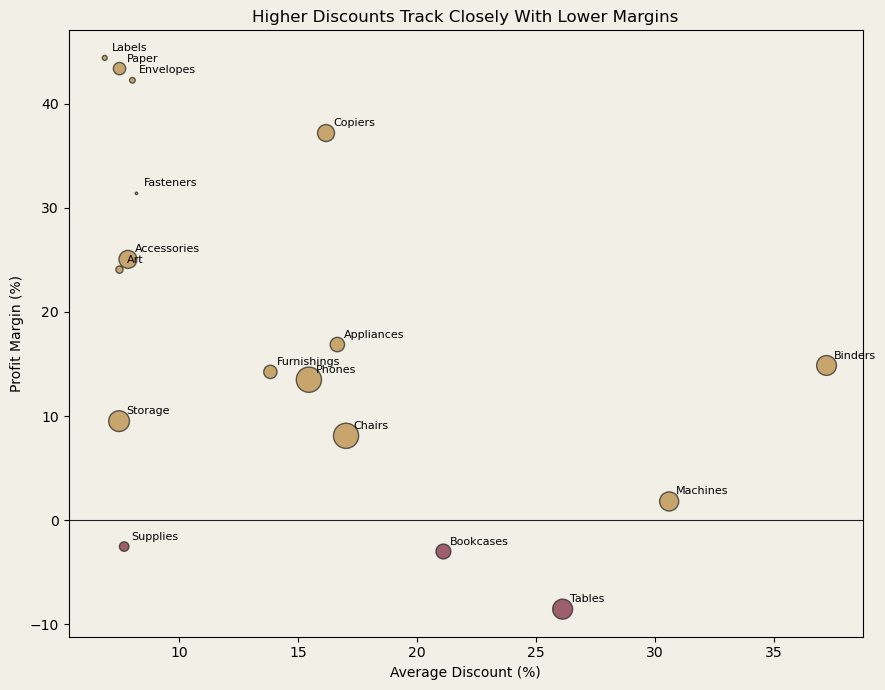

In [15]:
discount_summary = df.groupby('Sub-Category').agg(
    avg_discount=('Discount', 'mean'),
    margin=('Profit', 'sum')
)
discount_summary['sales'] = df.groupby('Sub-Category')['Sales'].sum()
discount_summary['margin_pct'] = (discount_summary['margin'] / discount_summary['sales']) * 100
discount_summary['avg_discount_pct'] = discount_summary['avg_discount'] * 100

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#7A2436' if x < 0 else '#B8863B' for x in discount_summary['margin_pct']]
ax.scatter(discount_summary['avg_discount_pct'], discount_summary['margin_pct'], 
           s=discount_summary['sales']/1000, color=colors, alpha=0.7, edgecolors='#1C2321')

for label, row in discount_summary.iterrows():
    ax.annotate(label, (row['avg_discount_pct'], row['margin_pct']), 
                fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.axhline(0, color='#1C2321', linewidth=0.8)
ax.set_xlabel('Average Discount (%)')
ax.set_ylabel('Profit Margin (%)')
ax.set_title('Higher Discounts Track Closely With Lower Margins', fontsize=12)
ax.set_facecolor('#F1EFE6')
fig.patch.set_facecolor('#F1EFE6')
plt.tight_layout()
plt.savefig('discount_vs_margin.png', dpi=200, bbox_inches='tight')
plt.show()

In [17]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Quarter'] = df['Order Date'].dt.to_period('Q')

quarterly = df.groupby('Quarter')[['Sales', 'Profit']].sum()
quarterly['Margin %'] = (quarterly['Profit'] / quarterly['Sales'] * 100).round(1)

tables_q = df[df['Sub-Category'] == 'Tables'].groupby('Quarter')[['Sales', 'Profit']].sum()
tables_q['Margin %'] = (tables_q['Profit'] / tables_q['Sales'] * 100).round(1)

bookcases_q = df[df['Sub-Category'] == 'Bookcases'].groupby('Quarter')[['Sales', 'Profit']].sum()
bookcases_q['Margin %'] = (bookcases_q['Profit'] / bookcases_q['Sales'] * 100).round(1)

print("Overall margin by quarter:")
print(quarterly['Margin %'])
print("\nTables margin by quarter:")
print(tables_q['Margin %'])

Overall margin by quarter:
Quarter
2014Q1     5.1
2014Q2    12.9
2014Q3     8.9
2014Q4    12.1
2015Q1    13.5
2015Q2    13.7
2015Q3    12.9
2015Q4    12.8
2016Q1    12.3
2016Q2    12.0
2016Q3    11.0
2016Q4    16.2
2017Q1    19.1
2017Q2    11.6
2017Q3    13.8
2017Q4     9.8
Freq: Q-DEC, Name: Margin %, dtype: float64

Tables margin by quarter:
Quarter
2014Q1   -16.0
2014Q2    -3.8
2014Q3    -4.1
2014Q4    -5.8
2015Q1   -14.1
2015Q2   -27.2
2015Q3    -7.9
2015Q4    -2.4
2016Q1   -11.3
2016Q2    -2.3
2016Q3    -1.9
2016Q4    -6.1
2017Q1   -13.7
2017Q2   -15.2
2017Q3   -11.8
2017Q4   -13.4
Freq: Q-DEC, Name: Margin %, dtype: float64


In [19]:
furniture_losses = df[df['Sub-Category'].isin(['Tables', 'Bookcases'])]

region_summary = furniture_losses.groupby('Region')[['Sales', 'Profit']].sum()
region_summary['Margin %'] = (region_summary['Profit'] / region_summary['Sales'] * 100).round(1)
region_summary = region_summary.sort_values('Margin %')
print(region_summary)

state_summary = furniture_losses.groupby('State')[['Sales', 'Profit']].sum()
state_summary['Margin %'] = (state_summary['Profit'] / state_summary['Sales'] * 100).round(1)
print(state_summary.sort_values('Profit').head(8))

               Sales      Profit  Margin %
Region                                    
East      82959.1410 -12193.0119     -14.7
Central   63312.1478  -5557.5547      -8.8
South     54815.5540  -3283.5661      -6.0
West     120758.6855   -163.9044      -0.1
                     Sales     Profit  Margin %
State                                          
Pennsylvania    13282.9410 -5485.5139     -41.3
Illinois        10833.3680 -4865.6173     -44.9
Texas           30254.1198 -4607.8143     -15.2
New York        36556.1620 -4184.7664     -11.4
Ohio             9964.8190 -4074.3861     -40.9
North Carolina  10640.7880 -3782.2319     -35.5
Colorado         3040.6530 -3383.7917    -111.3
Arizona          4514.5630 -3151.0774     -69.8


In [21]:
tables_df = df[df['Sub-Category'] == 'Tables'].copy()
tables_df['Margin'] = tables_df['Profit'] / tables_df['Sales']

correlation = tables_df['Discount'].corr(tables_df['Margin'])
print(f"Correlation between Discount and Margin (Tables only): r = {correlation:.3f}")

furniture_df = df[df['Category'] == 'Furniture'].copy()
furniture_df['Margin'] = furniture_df['Profit'] / furniture_df['Sales']
correlation_furniture = furniture_df['Discount'].corr(furniture_df['Margin'])
print(f"Correlation between Discount and Margin (Furniture only): r = {correlation_furniture:.3f}")

Correlation between Discount and Margin (Tables only): r = -0.930
Correlation between Discount and Margin (Furniture only): r = -0.888
